# 📈 Time-Series Trend & Rolling Metrics Analysis

Welcome to the **Time-Series Trend & Rolling Metrics** analysis notebook. In this notebook, we examine how daily operational fluctuations (noise) can obscure long-term trends (signal). By implementing resampling, rolling averages, percentage changes, and cumulative metrics, we will transform raw transactional noise into a reliable analytical dashboard for strategic decision-making.

## 🎯 Learning Objectives / Requirements Met:
1. **Task 1**: Resample daily data into weekly and monthly buckets, using multiple aggregation functions (`sum`, `count`, `mean`).
2. **Task 2**: Compute 7-day and 30-day rolling averages and plot raw data alongside both averages.
3. **Task 3**: Calculate Month-over-Month percentage changes, documenting growth vs. decline phases.
4. **Task 4**: Compute cumulative sum for revenue and visualize cumulative growth.
5. **Task 5**: Identify trend direction, calculate magnitude of change, and document business implications and suggested action plans.

## 💡 Core Conceptual Foundations

Before diving into the analysis, let's establish the key time-series concepts that will guide our workflow:

### 1. Resampling vs. GroupBy
- **`resample()`** is date-aware. It understands temporal relationships, gaps, and chronological ordering. It can automatically fill date gaps, upsample (fill in missing intervals), or downsample (aggregate daily to monthly). It automatically orders the index chronologically.
- **`groupby()`** treats dates as discrete labels (like categories). If a date is missing, `groupby()` simply omits it without understanding that a gap exists in the timeline. It lacks time-series-specific operations like forward-fill, interpolation, or physical date offsets.

### 2. Rolling Window Mechanics
- A **Rolling Window** slides across chronological data. At each point, it computes an aggregate (like `.mean()`) over the preceding $N$ periods (e.g. 7 or 30 days).
- **Window Size Trade-offs**:
  - **Short Window (e.g., 7 days)**: Responsive to recent changes, low lag. However, it still contains weekly noise (e.g., weekend dips) and doesn't reveal the true underlying quarterly trend.
  - **Long Window (e.g., 30 days)**: Smooths out weekly noise entirely. Reveals the structural health of the business. However, it introduces lag at turning/inflection points.

### 3. MoM Change & Negative Values
- **`.pct_change()`** calculates the rate of change between periods: $(V_{t} - V_{t-1}) / V_{t-1}$.
- **Negative Values** mean contraction or declining velocity. If month-over-month change goes from $+10\%$ to $-5\%$, it indicates the business did not just grow slower; it actually generated less revenue than the prior month. If it goes from $+15\%$ to $+5\%$, it means growth is positive but *decelerating*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

BASE_DIR = Path("..")
RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "daily_revenue.csv"
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "daily_revenue_processed.csv"
OUTPUT_DIR = BASE_DIR / "output"

print("Libraries loaded. Paths initialized.")

Libraries loaded. Paths initialized.


## 🛠️ Data Loading & Time-Series Imputation (Gaps Handling)

Real-world time-series data often contains gaps due to system outages, holidays, or logging failures. Before analyzing trends, we must detect and handle these gaps.

Let's load the raw daily revenue dataset (which includes simulated missing dates/gaps) and review the missing counts.

In [2]:
# Load raw daily revenue data
df_raw = pd.read_csv(RAW_DATA_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])
print(f"Raw dataset shape: {df_raw.shape[0]} rows")

# Find missing dates
null_rev = df_raw['revenue'].isnull().sum()
null_orders = df_raw['orders'].isnull().sum()
print(f"Missing revenue entries: {null_rev}")
print(f"Missing orders entries: {null_orders}")

# Display some rows with missing data
df_raw[df_raw['revenue'].isnull()].head()

Raw dataset shape: 546 rows
Missing revenue entries: 15
Missing orders entries: 15


,date,revenue,orders
136,2025-05-17,NaN,NaN
243,2025-09-01,NaN,NaN
253,2025-09-11,NaN,NaN
259,2025-09-17,NaN,NaN
260,2025-09-18,NaN,NaN


### Missing Data Strategy
For continuous numeric metrics like `revenue`, **linear interpolation** (`.interpolate(method='linear')`) estimates the missing values by drawing a straight line between the surrounding dates. For counts like `orders`, we can use **forward-fill** (`.ffill()`) which propagates the last known count forward.

In [3]:
# Apply time-series imputation
df = df_raw.copy()
df['revenue'] = df['revenue'].interpolate(method='linear')
df['orders'] = df['orders'].ffill().bfill().astype(int)

print(f"Remaining missing values in revenue: {df['revenue'].isnull().sum()}")
print(f"Remaining missing values in orders: {df['orders'].isnull().sum()}")

# Save processed dataset
df.to_csv(PROCESSED_DATA_PATH, index=False)
print("Processed dataset successfully written.")

Remaining missing values in revenue: 0
Remaining missing values in orders: 0
Processed dataset successfully written.


## 📊 Task 1: Resampling Data by Time Period

We aggregate the cleaned daily dataset into weekly (`W`) and monthly (`ME`) frequencies. This changes the perspective from noisy daily updates to aggregated business intervals.

In [4]:
# Set date as index for resample operation
df_ts = df.set_index('date')

# Weekly Aggregations
weekly_revenue = df_ts['revenue'].resample('W').sum()
weekly_count = df_ts['orders'].resample('W').count()
weekly_avg = df_ts['revenue'].resample('W').mean()

# Monthly Aggregations
monthly_revenue = df_ts['revenue'].resample('ME').sum()
monthly_orders = df_ts['orders'].resample('ME').sum()
monthly_avg = df_ts['revenue'].resample('ME').mean()

print("--- Task 1 Resampling Outputs ---")
print(f"Weekly revenue sample (first 3 weeks):\n{weekly_revenue.head(3)}\n")
print(f"Monthly revenue sample (first 3 months):\n{monthly_revenue.head(3)}\n")

# Identify highest revenue periods
max_week = weekly_revenue.idxmax()
max_month = monthly_revenue.idxmax()
print(f"Highest Revenue Week: {max_week.strftime('%Y-%m-%d')} (${weekly_revenue[max_week]:,.2f})")
print(f"Highest Revenue Month: {max_month.strftime('%B %Y')} (${monthly_revenue[max_month]:,.2f})")

--- Task 1 Resampling Outputs ---
Weekly revenue sample (first 3 weeks):
date
2025-01-05    221135.044615
2025-01-12    306169.346397
2025-01-19    286929.606406
Freq: W-SUN, Name: revenue, dtype: float64

Monthly revenue sample (first 3 months):
date
2025-01-31    1.312887e+06
2025-02-28    1.223124e+06
2025-03-31    1.405436e+06
Freq: ME, Name: revenue, dtype: float64

Highest Revenue Week: 2026-04-26 ($403,537.83)
Highest Revenue Month: May 2026 ($1,726,898.94)


## 📈 Task 2: Compute Rolling Window Average

Here we compute 7-day and 30-day moving averages. Daily numbers are highly volatile due to a weekly cyclical pattern. Rolling averages smooth out this volatility.

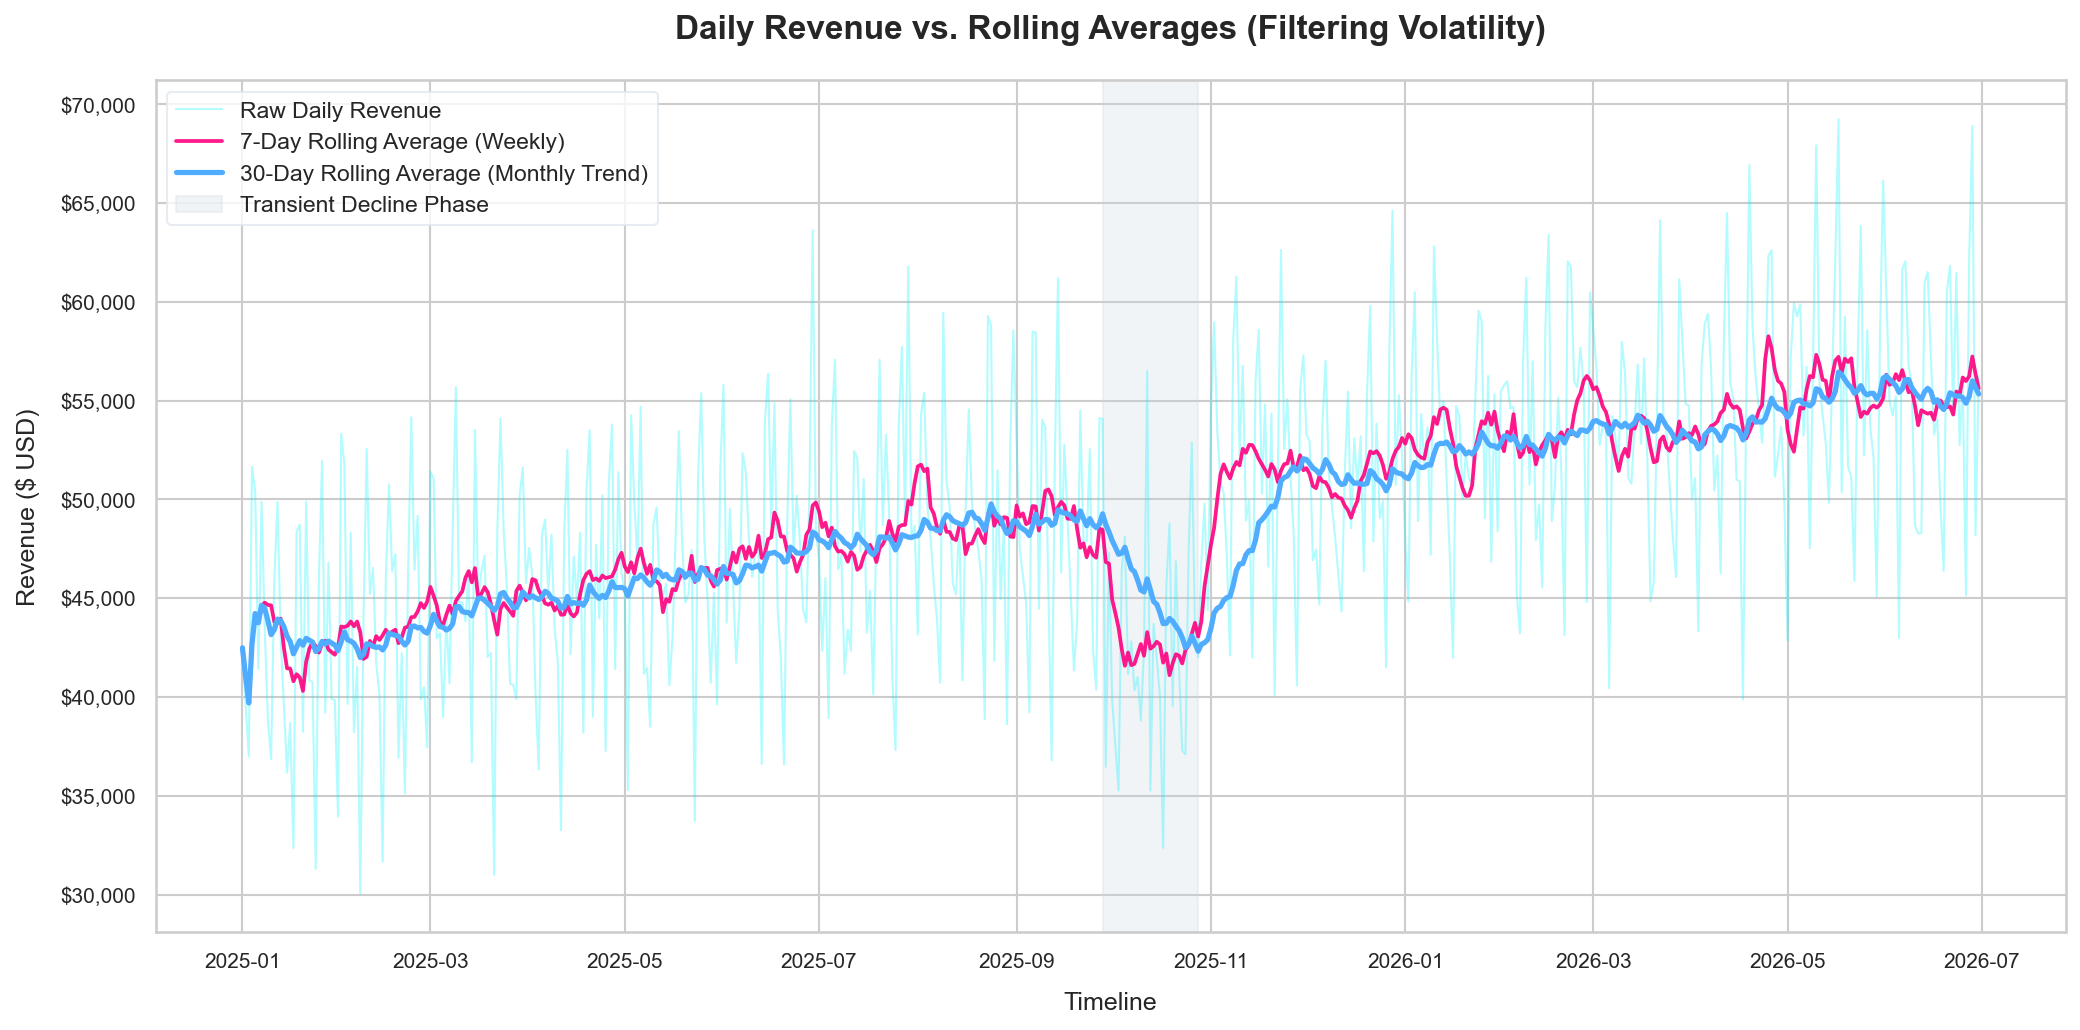

Plot saved to: ..\output\rolling_avg.png


In [5]:
# Compute rolling averages on daily data
df['revenue_ma7'] = df['revenue'].rolling(window=7, min_periods=1).mean()
df['revenue_ma30'] = df['revenue'].rolling(window=30, min_periods=1).mean()

# Create premium plot comparing raw vs. rolling averages
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

ax.plot(df['date'], df['revenue'], label='Raw Daily Revenue', color='#00f2fe', alpha=0.3, linewidth=1)
ax.plot(df['date'], df['revenue_ma7'], label='7-Day Rolling Average (Weekly)', color='#ff007f', alpha=0.9, linewidth=1.8)
ax.plot(df['date'], df['revenue_ma30'], label='30-Day Rolling Average (Monthly Trend)', color='#4facfe', alpha=1.0, linewidth=2.5)

# Formats
ax.set_title('Daily Revenue vs. Rolling Averages (Filtering Volatility)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Timeline', fontsize=12, labelpad=10)
ax.set_ylabel('Revenue ($ USD)', fontsize=12, labelpad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

# Highlight the decline event in October 2025
ax.axvspan(pd.Timestamp("2025-09-28"), pd.Timestamp("2025-10-28"), color='#cbd5e1', alpha=0.25, label='Transient Decline Phase')

ax.legend(frameon=True, facecolor='white', edgecolor='#e2e8f0', fontsize=11, loc='upper left')
plt.tight_layout()

# Save plot
plot_path = OUTPUT_DIR / "rolling_avg.png"
plt.savefig(plot_path, facecolor='white', bbox_inches='tight')
plt.show()
print(f"Plot saved to: {plot_path}")

## 📉 Task 3: Calculate Month-over-Month Percentage Change

Percentage changes show growth velocity. We analyze the growth rates across the months of 2025 and 2026.

In [6]:
# Calculate MoM percentage change
mom_change = monthly_revenue.pct_change() * 100

# Segment growth vs decline months
growth_months = mom_change[mom_change > 0]
decline_months = mom_change[mom_change < 0]

print("--- Growth Months (> 0% MoM) ---")
for date, val in growth_months.items():
    print(f"  {date.strftime('%B %Y')}: {val:+.1f}%")

print("\n--- Decline Months (< 0% MoM) ---")
for date, val in decline_months.items():
    print(f"  {date.strftime('%B %Y')}: {val:+.1f}%")

--- Growth Months (> 0% MoM) ---
  March 2025: +14.9%
  May 2025: +4.1%
  June 2025: +1.7%
  July 2025: +3.0%
  August 2025: +1.3%
  November 2025: +17.7%
  December 2025: +1.9%
  January 2026: +2.6%
  March 2026: +10.0%
  May 2026: +5.8%

--- Decline Months (< 0% MoM) ---
  February 2025: -6.8%
  April 2025: -2.8%
  September 2025: -4.0%
  October 2025: -8.5%
  February 2026: -7.9%
  April 2026: -1.3%
  June 2026: -3.9%


## 💰 Task 4: Compute Cumulative Sum

Tracking cumulative metrics helps stakeholders evaluate total aggregate growth. We calculate the running total of revenue accumulated over the 18 months.

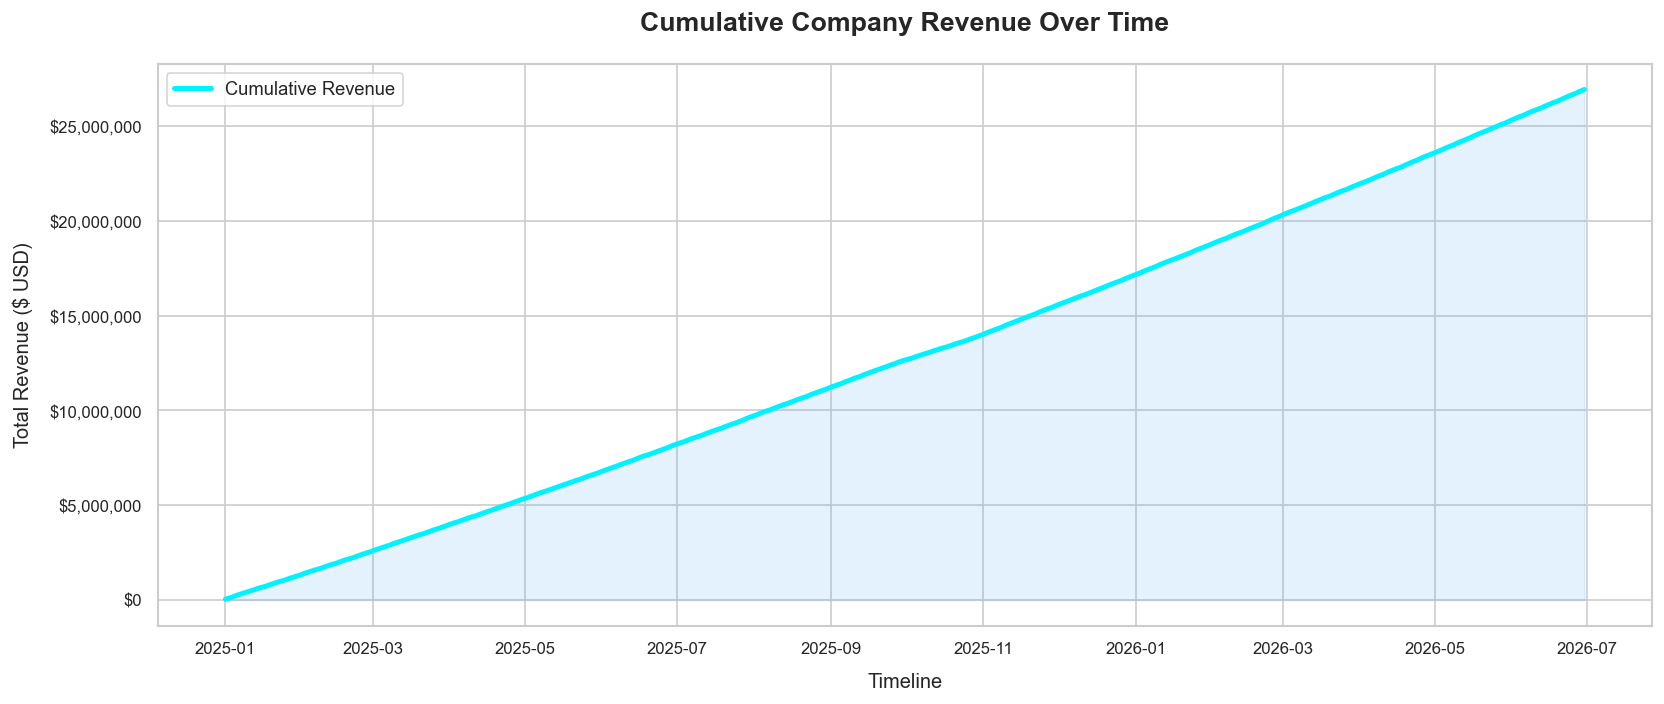

Total Accumulated Revenue by end of period: $26,922,508.95


In [7]:
# Compute cumulative revenue
df['cumulative_revenue'] = df['revenue'].cumsum()

# Plot cumulative revenue growth
fig, ax = plt.subplots(figsize=(14, 6), dpi=120)
ax.fill_between(df['date'], df['cumulative_revenue'], color='#4facfe', alpha=0.15)
ax.plot(df['date'], df['cumulative_revenue'], color='#00f2fe', linewidth=3, label='Cumulative Revenue')

ax.set_title('Cumulative Company Revenue Over Time', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Timeline', fontsize=12, labelpad=10)
ax.set_ylabel('Total Revenue ($ USD)', fontsize=12, labelpad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
ax.legend(loc='upper left')

plt.tight_layout()
cumulative_plot_path = OUTPUT_DIR / "cumulative.png"
plt.savefig(cumulative_plot_path, facecolor='white', bbox_inches='tight')
plt.show()

print(f"Total Accumulated Revenue by end of period: ${df['cumulative_revenue'].iloc[-1]:,.2f}")

## 🛡️ Task 5: Identify Trend Pattern & Business Implications

Let's measure the latest trend direction and magnitude using the 30-day rolling average, and connect these observations to operational decisions.

In [8]:
# Trend direction in the last 30 days
recent_ma30 = df['revenue_ma30'].iloc[-30:]
start_val = recent_ma30.iloc[0]
end_val = recent_ma30.iloc[-1]

trend_direction = "UP" if end_val > start_val else "DOWN" if end_val < start_val else "FLAT"
trend_magnitude = ((end_val - start_val) / start_val) * 100
daily_std = df['revenue'].std()
avg_daily_rev = df['revenue'].mean()
noise_ratio = (daily_std / avg_daily_rev) * 100

print(f"--- Trend Metrics ---")
print(f"Trend Direction: {trend_direction}")
print(f"Change over last 30 days: {trend_magnitude:+.2f}%")
print(f"Daily Volatility (Std Dev): ${daily_std:,.2f} ({noise_ratio:.1f}% of mean)")

# Implication Logic
if trend_direction == "UP":
    implication = "Accelerating growth - Maintain strategy, scale user acquisition, and ignore short-term fluctuations."
else:
    implication = "Declining momentum - Investigate recent operational adjustments, user retention drop, or pricing pressure."

print(f"\nBusiness Implication: {implication}")

--- Trend Metrics ---
Trend Direction: DOWN
Change over last 30 days: -1.61%
Daily Volatility (Std Dev): $7,060.07 (14.3% of mean)

Business Implication: Declining momentum - Investigate recent operational adjustments, user retention drop, or pricing pressure.
